4. RANDOM SURVIVAL FOREST
- El objetivo de esta sección es comparar el modelo de Cox con un modelo de ML (RSF), y evaluar cuál predice mejor la supervivencia usando el C-index y el Brier score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, brier_score
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

luad = pd.read_csv("../data/tcga_luad_modelo.csv")
luad["estadio"] = pd.Categorical(luad["estadio"], categories=["I","II","III","IV"], ordered=True)

print(f"Pacientes cargados: {len(luad)}")
luad.head()

Pacientes cargados: 509


,tiempo_anios,evento,estadio,age_at_index,grupo_edad,sexo,ajcc_pathologic_n,ajcc_pathologic_m,primary_diagnosis
0,2.836413,0,I,60.0,55-65,Mujer,N0,M0,"Adenocarcinoma, NOS"
1,1.993155,0,NaN,64.0,55-65,Hombre,NaN,NaN,Mucinous adenocarcinoma
2,0.380561,1,III,65.0,65-75,Mujer,N2,M0,Adenocarcinoma with mixed subtypes
3,1.409993,0,I,87.0,>75,Mujer,N0,MX,"Adenocarcinoma, NOS"
4,2.264203,0,II,60.0,55-65,Hombre,N0,MX,"Squamous cell carcinoma, NOS"


In [2]:
#Se necesita un formato especial para la variable outcome:
#un array estructurado con (evento_bool, tiempo)

#Reutilizo la misma preparación que en Cox
luad_rsf = luad.copy()
luad_rsf["estadio_num"] = luad_rsf["estadio"].map({"I":1, "II":2, "III":3, "IV":4})
luad_rsf["sexo_hombre"] = (luad_rsf["sexo"] == "Hombre").astype(int)
luad_rsf["n_positivo"]  = (luad_rsf["ajcc_pathologic_n"].isin(["N1","N2","N3"])).astype(int)
luad_rsf["m_positivo"]  = (luad_rsf["ajcc_pathologic_m"].isin(["M1","M1a","M1b"])).astype(int)

luad_rsf = luad_rsf.dropna(subset=["estadio_num", "age_at_index"]).copy()

#Variables predictoras
X = luad_rsf[["estadio_num", "age_at_index", "sexo_hombre", "n_positivo", "m_positivo"]]

#Variable outcome en formato estructurado comentado previamente
y = Surv.from_arrays(
    event=luad_rsf["evento"].astype(bool),
    time=luad_rsf["tiempo_anios"]
)

#División en train (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {len(X_train)} pacientes")
print(f"Test:  {len(X_test)} pacientes")

Train: 266 pacientes
Test:  115 pacientes


In [3]:
#4.1. COMPARATIVA DE RENDIMIENTO
#Entrenamiento del Random Survival Forest
rsf = RandomSurvivalForest(
    n_estimators=100,    #número de árboles
    min_samples_leaf=10, #mínimo de pacientes en cada hoja
    max_features="sqrt", #variables consideradas en cada split
    random_state=42,
    n_jobs=-1            #usa todos los núcleos del procesador
)

rsf.fit(X_train, y_train)

#C-index en test
c_index = concordance_index_censored(
    y_test["event"],
    y_test["time"],
    rsf.predict(X_test)
)

print(f"C-index RSF (test): {c_index[0]:.3f}")
print(f"C-index Cox        0.670  (referencia)")

C-index RSF (test): 0.618
C-index Cox        0.670  (referencia)


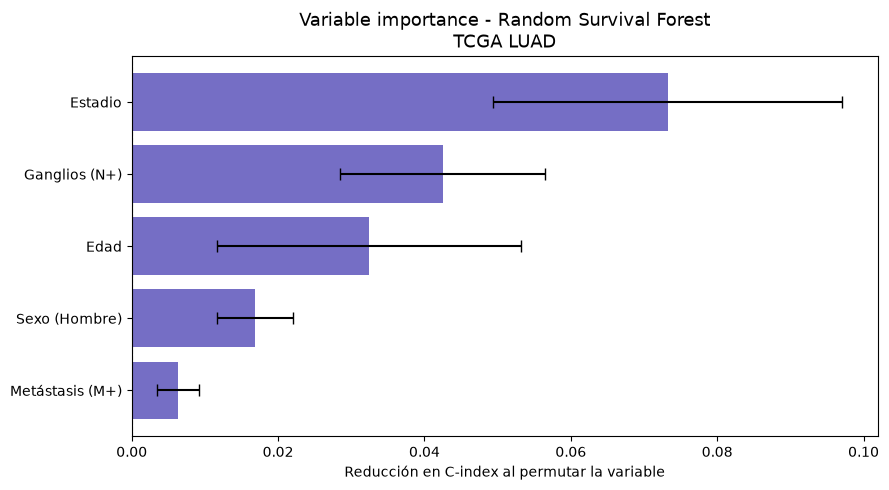

In [4]:
#4.2. VARIABLE IMPORTANCE por permutación
#mira cuánto empeora el C-index del modelo al tomar una variable, y barajar aleatoriamente sus valores entre todos los pacientes
result = permutation_importance(
    rsf, X_test, y_test,
    n_repeats=10,
    random_state=42
)

#organizo los resultados en una tabla, ordenada de menos importante a más
importance_df = pd.DataFrame({
    "Variable": ["Estadio", "Edad", "Sexo (Hombre)", "Ganglios (N+)", "Metástasis (M+)"],
    "Importance": result.importances_mean,
    "Std": result.importances_std
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(importance_df["Variable"], importance_df["Importance"],
        xerr=importance_df["Std"], color="#534AB7", alpha=0.8, capsize=4)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Variable importance - Random Survival Forest\nTCGA LUAD", fontsize=13)
ax.set_xlabel("Reducción en C-index al permutar la variable")

plt.tight_layout()
plt.savefig("../figures/rsf_importance.png", dpi=150, bbox_inches="tight")
plt.show()
